In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))

# read_colvar function which sorts colvar for unique entries from the back (i.e., second entry retained)
def read_colvar(colvar_file):

    data = np.loadtxt(colvar_file)
    # inverse order
    data = data[::-1]
    unique_idxs = np.array(np.unique(data[:,0], return_index=True)[1]).astype(int)[::-1] # find unique indices, first occurences
    data = data[unique_idxs]
    # original order
    data = data[::-1]

    return data


path = '/Volumes/Elements/PTM_project/PARK7/repeat_TYR_COORD_METAD_chainA_BF40/DATA_PLUMED/'

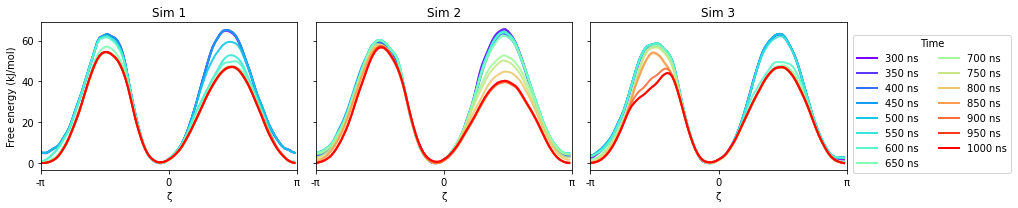

In [16]:


T = 298
sims = [1, 2, 3]

times = np.arange(300, 1050, 50)
colors = plt.cm.rainbow(np.linspace(0, 1, len(times)))

frame_per_ns = 1000 / 5
init_frame = int(200 * frame_per_ns)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

# Create legend handles (one per time)
legend_handles = [
    plt.Line2D([0], [0], color=c, lw=2, label=f'{t} ns')
    for t, c in zip(times, colors)
]

for ax, sim in zip(axes, sims):

    data = np.loadtxt(path + f'COLVAR.{sim}')
    CV = data[:, 1]
    rbias = data[:, 4]

    for t, c in zip(times, colors):

        frame = int(t * frame_per_ns)
        if frame <= init_frame:
            continue

        kbt = 0.008314 * T

        rb_slice = rbias[init_frame:frame]
        cv_slice = CV[init_frame:frame]

        weights = np.exp((rb_slice - np.max(rb_slice)) / kbt)
        weights /= np.sum(weights)

        hist, x = np.histogram(cv_slice, weights=weights, bins=100)
        p = hist / np.sum(hist)
        p[p == 0] = 1e-12

        fel = -kbt * np.log(p)
        fel = scipy.ndimage.gaussian_filter(fel, sigma=1)
        fel -= np.min(fel)

        ax.plot(x[:-1], fel, color=c, alpha=0.9, lw=2)

    ax.set_title(f'Sim {sim}')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels(['-\u03C0',0,'\u03C0'])
    ax.set_xlabel('\u03B6')

axes[0].set_ylabel('Free energy (kJ/mol)')

# Add a single shared legend
fig.legend(
    handles=legend_handles,
    loc='center right',
    title='Time',
    ncol=2,
    bbox_to_anchor=(1.18, 0.5)
)

plt.tight_layout()
plt.savefig('rbias_zeta_FEL_timecourse_all_sims.pdf', dpi=300, bbox_inches='tight')




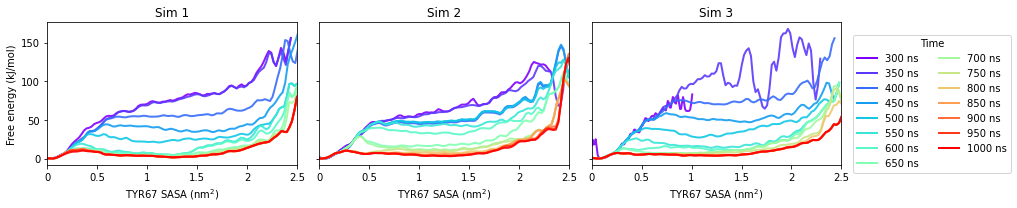

In [17]:


T = 298
sims = [1, 2, 3]

times = np.arange(300, 1050, 50)
colors = plt.cm.rainbow(np.linspace(0, 1, len(times)))

frame_per_ns = 1000 / 20 # 20 ps sampling for SASA data/calculation
init_frame = int(200 * frame_per_ns)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

# Create legend handles (one per time)
legend_handles = [
    plt.Line2D([0], [0], color=c, lw=2, label=f'{t} ns')
    for t, c in zip(times, colors)
]

for ax, sim in zip(axes, sims):

    data = read_colvar(path + f'COLVAR.{sim}')[::4] # downsample to 20 ps to match SASA data
    CV = np.loadtxt(path + f'../RMSD_SASA_data/sasa_chainA_TYR67_{sim}.xvg', skiprows=25)[:,2]
    rbias = data[:, 4]

    for t, c in zip(times, colors):

        frame = int(t * frame_per_ns)
        if frame <= init_frame:
            continue

        kbt = 0.008314 * T

        rb_slice = rbias[init_frame:frame]
        cv_slice = CV[init_frame:frame]

        weights = np.exp((rb_slice - np.max(rb_slice)) / kbt)
        weights /= np.sum(weights)

        hist, x = np.histogram(cv_slice, weights=weights, bins=100)
        p = hist / np.sum(hist)
        p[p == 0] = 1e-12

        fel = -kbt * np.log(p)
        fel = scipy.ndimage.gaussian_filter(fel, sigma=1)
        fel -= np.min(fel)

        ax.plot(x[:-1], fel, color=c, alpha=0.9, lw=2)

    ax.set_title(f'Sim {sim}')
    ax.set_xlim(0,2.5)
    ax.set_xticks([0,0.5,1,1.5,2,2.5])
    ax.set_xticklabels([0,0.5,1,1.5,2,2.5])
    ax.set_xlabel('TYR67 SASA (nm$^{2}$)')

axes[0].set_ylabel('Free energy (kJ/mol)')

# Add a single shared legend
fig.legend(
    handles=legend_handles,
    loc='center right',
    title='Time',
    ncol=2,
    bbox_to_anchor=(1.18, 0.5)
)

plt.tight_layout()
plt.savefig('rbias_SASA_FEL_timecourse_all_sims.pdf', dpi=300, bbox_inches='tight')





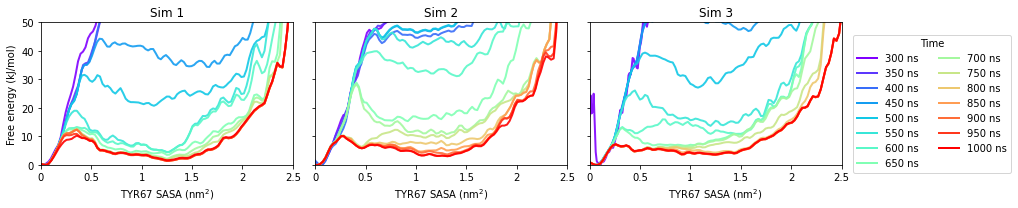

In [18]:


T = 298
sims = [1, 2, 3]

times = np.arange(300, 1050, 50)
colors = plt.cm.rainbow(np.linspace(0, 1, len(times)))

frame_per_ns = 1000 / 20 # 20 ps sampling for SASA data/calculation
init_frame = int(200 * frame_per_ns)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

# Create legend handles (one per time)
legend_handles = [
    plt.Line2D([0], [0], color=c, lw=2, label=f'{t} ns')
    for t, c in zip(times, colors)
]

for ax, sim in zip(axes, sims):

    data = read_colvar(path + f'COLVAR.{sim}')[::4] # downsample to 20 ps to match SASA data
    CV = np.loadtxt(path + f'../RMSD_SASA_data/sasa_chainA_TYR67_{sim}.xvg', skiprows=25)[:,2]
    rbias = data[:, 4]

    for t, c in zip(times, colors):

        frame = int(t * frame_per_ns)
        if frame <= init_frame:
            continue

        kbt = 0.008314 * T

        rb_slice = rbias[init_frame:frame]
        cv_slice = CV[init_frame:frame]

        weights = np.exp((rb_slice - np.max(rb_slice)) / kbt)
        weights /= np.sum(weights)

        hist, x = np.histogram(cv_slice, weights=weights, bins=100)
        p = hist / np.sum(hist)
        p[p == 0] = 1e-12

        fel = -kbt * np.log(p)
        fel = scipy.ndimage.gaussian_filter(fel, sigma=1)
        fel -= np.min(fel)

        ax.plot(x[:-1], fel, color=c, alpha=0.9, lw=2)

    ax.set_title(f'Sim {sim}')
    ax.set_xlim(0,2.5)
    ax.set_ylim(0,50)
    ax.set_xticks([0,0.5,1,1.5,2,2.5])
    ax.set_xticklabels([0,0.5,1,1.5,2,2.5])
    ax.set_xlabel('TYR67 SASA (nm$^{2}$)')

axes[0].set_ylabel('Free energy (kJ/mol)')

# Add a single shared legend
fig.legend(
    handles=legend_handles,
    loc='center right',
    title='Time',
    ncol=2,
    bbox_to_anchor=(1.18, 0.5)
)

plt.tight_layout()
plt.savefig('rbias_SASA_FEL_timecourse_all_sims_zoomed.pdf', dpi=300, bbox_inches='tight')






<Figure size 288x216 with 0 Axes>

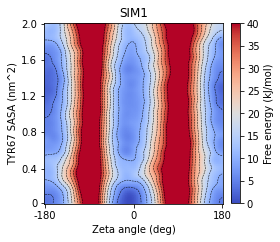

In [10]:
# FEL of sim1

sim = 1
T = 298

t= 1000
t_discard = 200


data = read_colvar(path+'COLVAR.{}'.format(sim))[::4]
zeta = data[:,1]
SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(sim),skiprows=25)[:,2]
rbias = data[:,4]

xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
yedges = np.arange(0,2.02,0.02)

frame = int(t*1000/20)
init_frame = int(t_discard*1000/20)
    
# FEL rbias reweighting
kbt = 0.008314*T

plt.figure(figsize = (4,3))


weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
weights = weights/np.sum(weights)

x=zeta[init_frame:frame]
y=SASA[init_frame:frame]

H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H) # convert counts to probility
h = -kbt*np.log(h) # calculate free energy from probability
h = h-np.min(h) # set minimum to 0 kbT
h = h.T


max_energy = 40
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='coolwarm')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-180','0','180']
ylabels = [0,0.4,0.8,1.2,1.6,2.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))
plt.title('SIM{}'.format(sim))
plt.xlabel('Zeta angle (deg)')
plt.ylabel('TYR67 SASA (nm^2)')

plt.tight_layout()
plt.savefig('2D_zeta_vs_SASA_sim{}.png'.format(sim))

<Figure size 288x216 with 0 Axes>

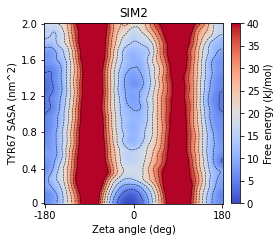

In [11]:
# convergence with rbias 

sim = 2
T = 298

t= 1000
t_discard = 200


data = read_colvar(path+'COLVAR.{}'.format(sim))[::4]
zeta = data[:,1]
SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(sim),skiprows=25)[:,2]
rbias = data[:,4]

xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
yedges = np.arange(0,2.02,0.02)

frame = int(t*1000/20)
init_frame = int(t_discard*1000/20)
    
# FEL rbias reweighting
kbt = 0.008314*T

plt.figure(figsize = (4,3))


weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
weights = weights/np.sum(weights)

x=zeta[init_frame:frame]
y=SASA[init_frame:frame]

H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H) # convert counts to probility
h = -kbt*np.log(h) # calculate free energy from probability
h = h-np.min(h) # set minimum to 0 kbT
h = h.T


max_energy = 40
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='coolwarm')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-180','0','180']
ylabels = [0,0.4,0.8,1.2,1.6,2.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))
plt.title('SIM{}'.format(sim))
plt.xlabel('Zeta angle (deg)')
plt.ylabel('TYR67 SASA (nm^2)')

plt.tight_layout()
plt.savefig('2D_zeta_vs_SASA_sim{}.png'.format(sim))

<Figure size 288x216 with 0 Axes>

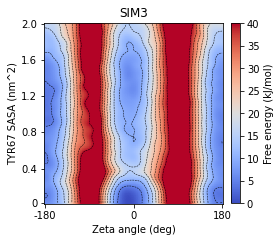

In [12]:
# convergence with rbias 

sim = 3
T = 298

t= 1000
t_discard = 200


data = read_colvar(path+'COLVAR.{}'.format(sim))[::4]
zeta = data[:,1]
SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(sim),skiprows=25)[:,2]
rbias = data[:,4]

xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
yedges = np.arange(0,2.02,0.02)

frame = int(t*1000/20)
init_frame = int(t_discard*1000/20)
    
# FEL rbias reweighting
kbt = 0.008314*T

plt.figure(figsize = (4,3))


weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
weights = weights/np.sum(weights)

x=zeta[init_frame:frame]
y=SASA[init_frame:frame]

H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H) # convert counts to probility
h = -kbt*np.log(h) # calculate free energy from probability
h = h-np.min(h) # set minimum to 0 kbT
h = h.T


max_energy = 40
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='coolwarm')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-180','0','180']
ylabels = [0,0.4,0.8,1.2,1.6,2.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))
plt.title('SIM{}'.format(sim))
plt.xlabel('Zeta angle (deg)')
plt.ylabel('TYR67 SASA (nm^2)')

plt.tight_layout()
plt.savefig('2D_zeta_vs_SASA_sim{}.png'.format(sim))

In [20]:
# calculate fraction open/close 



# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


vals = []


for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))[::4] # 20 ps sampling
    CV = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    openframes = np.where(SASA[init_frame:frame]>0.35)[0] 

    
    vals.append(np.sum(weights[openframes])/np.sum(weights))
    
# average and error

mu = np.round(np.mean(vals),2)
err = np.round(np.std(vals)/np.sqrt(nsims),2)


df = pd.DataFrame()
df['States'] = ['open','closed']
df['Avg'] = [mu,1-mu]
df['Error']  = [err,err]
df.to_csv('avg_open_probability.csv')
df

,States,Avg,Error
0,open,0.63,0.03
1,closed,0.37,0.03


In [26]:
# calculate fraction open/close 



# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


vals = []


for s in range(1,nsims+1):
    data = np.loadtxt(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[:frame]-np.amax(rbias[:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    openframes = np.where(SASA[:frame]>0.35)[0] 

    
    vals.append(np.sum(weights[openframes])/np.sum(weights))
    
# average and error

mu = np.round(np.mean(vals),3)
err = np.round(np.std(vals)/np.sqrt(nsims),3)


df = pd.DataFrame()
df['States'] = ['open','closed']
df['Avg'] = [mu,1-mu]
df['Error']  = [err,err]
df.to_csv('avg_open_probability_finalbias.csv')
df

,States,Avg,Error
0,open,0.68,0.134
1,closed,0.32,0.134
